In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import pickle
import sys
import os
import joblib

# Project-specific config import
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import config

from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

# Add project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))


In [3]:
from cProfile import label

project_root = Path("/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/")
# data_dir = project_root / "ML" / "Data" 


### 1) Set Paths + Labels 

In [4]:
OUT = Path(project_root)
TRAIN_NAME = "SNP_merged_train"

CV_DIR = OUT / TRAIN_NAME / "CVDatasets"
MODEL_DIR = OUT / TRAIN_NAME / "models" / "pickledModels"

CLASS_LABEL = "label"
ID_LABEL = "sample_id"   # set to None if your new data does not have it


### 2) Point to your new test file


In [5]:
original_test_data = pd.read_csv("/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/data/SNPRepData/SNP_merged_test.csv")
processed_test = pd.read_csv(project_root / "SNP_merged_train" / "replication" / "SNP_merged_test" / "SNP_merged_test_Processed.csv")


In [6]:
cv0_train_path = CV_DIR / f"{TRAIN_NAME}_CV_0_Train.csv"  # uses your existing CV_DIR/TRAIN_NAME


In [7]:
original_test_data.head()


,sample_id,SNP_0,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,SNP_7,SNP_8,...,SNP_56708,SNP_56709,SNP_56710,SNP_56711,SNP_56712,SNP_56713,SNP_56714,SNP_56715,SNP_56716,label
0,ERR1218582,0,0,0,1,1,0,1,1,1,...,0,1,1,1,0,1,1,0,2,R
1,ERR1218605,0,0,0,1,0,0,1,0,0,...,0,0,1,1,0,1,1,1,1,R
2,ERR1218607,0,0,0,1,1,0,1,1,1,...,0,1,1,1,0,1,1,0,2,R
3,ERR1218623,0,0,0,1,1,0,1,1,1,...,0,1,1,1,0,1,1,0,2,R
4,ERR1218646,0,1,1,1,0,0,1,0,0,...,0,0,1,1,0,1,1,1,1,R


In [8]:
original_test_data['label'] = original_test_data['label'].astype(str).str.strip().map({"R": 0, "S": 1})


In [9]:
original_test_data['label'].value_counts()


label
1    63
0    55
Name: count, dtype: int64

In [10]:
labels = original_test_data[["sample_id", "label"]].copy()
labels = labels.rename(columns={"label": "label_raw"})


In [11]:
test_encoded = processed_test.merge(labels, on="sample_id", how="left", validate="one_to_one")
print("Columns containing label:", [c for c in test_encoded.columns if "label" in c.lower()])
print("Missing labels:", test_encoded["label"].isna().sum())


Columns containing label: ['label', 'label_raw']
Missing labels: 0


In [12]:
test_encoded.head()


,sample_id,SNP_0,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,SNP_7,SNP_8,...,SNP_56699_1,SNP_56699_2,SNP_56700_0,SNP_56700_1,SNP_56700_2,SNP_56700_3,SNP_56716_0,SNP_56716_1,SNP_56716_2,label_raw
0,ERR1218582,0,0,0,1,1,0,1,1,1,...,True,False,False,True,False,0,0,0,0,0
1,ERR1218605,0,0,0,1,0,0,1,0,0,...,False,True,False,False,True,0,0,0,0,0
2,ERR1218607,0,0,0,1,1,0,1,1,1,...,True,False,False,True,False,0,0,0,0,0
3,ERR1218623,0,0,0,1,1,0,1,1,1,...,True,False,False,True,False,0,0,0,0,0
4,ERR1218646,0,1,1,1,0,0,1,0,0,...,True,False,False,True,False,0,0,0,0,0


In [13]:
cv0_train_path


PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/CVDatasets/SNP_merged_train_CV_0_Train.csv')

In [14]:
# Load CV train header
cv_cols = list(pd.read_csv(cv0_train_path, nrows=0).columns)
train_feature_cols = [c for c in cv_cols if c not in ["label", "sample_id"]]


In [15]:
test_encoded[cv_cols].isna().sum().sum()


np.int64(38)

In [16]:
feat_df = test_encoded[cv_cols].copy()
feat_df = feat_df.replace({None: 0}).fillna(0)


In [17]:
print("Train feature count:", len(train_feature_cols))


Train feature count: 5000


In [18]:

# Sanity check: all CV features must exist in processed test
missing_feats = [c for c in train_feature_cols if c not in test_encoded.columns]
if missing_feats:
    raise ValueError(
        f"Missing {len(missing_feats)} features in test_encoded that are present in CV train. "
        f"First few missing: {missing_feats[:20]}"
    )


In [19]:
len(missing_feats)


0

In [20]:
extra_feats = [
    c for c in test_encoded.columns
    if c not in train_feature_cols + ["sample_id", "label", "label_raw"]
]
print("Extra features in processed test:", len(extra_feats))


Extra features in processed test: 62259


In [21]:
# X: only the 5000 MI-selected features, in the exact train order
X = feat_df[train_feature_cols].to_numpy()


In [22]:
X.shape


(118, 5000)

In [23]:
# 2) Labels already encoded by STREAMLINE
y = test_encoded["label_raw"].astype(int).to_numpy()


In [24]:
y.shape 


(118,)

In [25]:
# 3) Sample IDs
ids = test_encoded["sample_id"].astype(str).to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique y values:", np.unique(y))


X shape: (118, 5000)
y shape: (118,)
Unique y values: [0 1]


In [26]:
cv_paths = sorted(Path(CV_DIR).glob(f"{TRAIN_NAME}_CV_*_Train.csv"))
for cv_path in cv_paths:
    cols = pd.read_csv(cv_path, nrows=0).columns
    feats = [c for c in cols if c not in ["label", "sample_id"]]
    print(f"{cv_path.name}: {len(feats)} features, hash={hash(tuple(feats))}")



SNP_merged_train_CV_0_Train.csv: 5000 features, hash=5794564731060112495
SNP_merged_train_CV_1_Train.csv: 5000 features, hash=2503831339771674022
SNP_merged_train_CV_2_Train.csv: 5000 features, hash=-4706075051362975579


In [ ]:
def build_test_matrix_for_fold(test_encoded, cv_train_csv, label_col="label_raw"):
    """
    Align processed test data to the feature space of a specific CV fold.

    test_encoded: processed test dataframe (has sample_id, label_raw, all 67k features)
    cv_train_csv: path to e.g. SNP_merged_train_CV_0_Train.csv
    label_col:    column in test_encoded with numeric labels (0/1)
    """
    # Get fold-specific feature list
    cv_cols = pd.read_csv(cv_train_csv, nrows=0).columns
    feat_cols = [c for c in cv_cols if c not in ["label", "sample_id"]]

    # Check all features are present in test
    missing = [c for c in feat_cols if c not in test_encoded.columns]
    if missing:
        raise ValueError(
            f"{cv_train_csv} expects {len(feat_cols)} features, "
            f"but {len(missing)} are missing in test_encoded. "
            f"First few missing: {missing[:20]}"
        )

    # Build X, y, ids
    X = test_encoded[feat_cols].to_numpy()
    y = test_encoded[label_col].astype(int).to_numpy()
    ids = test_encoded["sample_id"].astype(str).to_numpy()

    return X, y, ids, feat_cols


In [ ]:
cv_paths = sorted(Path(CV_DIR).glob(f"{TRAIN_NAME}_CV_*_Train.csv"))

for cv_path in cv_paths:
    print(f"\n=== {cv_path.name} ===")
    X_fold, y_fold, ids_fold, feat_cols_fold = build_test_matrix_for_fold(test_encoded, cv_path)
    print("X shape:", X_fold.shape, "y shape:", y_fold.shape)


In [29]:
print(X.shape, y.shape)


(118, 5000) (118,)


### Load the CVO trained model 

In [30]:
MODEL_DIR


PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/models/pickledModels')

In [31]:
list(MODEL_DIR.iterdir())


[PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/models/pickledModels/RF_2.pickle'),
 PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/models/pickledModels/LR_2.pickle'),
 PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/models/pickledModels/XGB_0.pickle'),
 PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/models/pickledModels/RF_1.pickle'),
 PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/models/pickledModels/RF_0.pickle'),
 PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/models/pickledModels/KNN_2.pickle'),
 PosixPath('/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/S

In [32]:
algo = "LR"
CV = 0 

model_path = MODEL_DIR / f"{algo}_{CV}.pickle"
model = joblib.load(model_path)


/Users/921623492/miniconda3/envs/abdoul_thesis/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [33]:
model 


,penalty,'l2'
,dual,False
,tol,0.0001
,C,2090.9008134216406
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,730
,multi_class,'auto'


In [34]:
model.get_params()


{'C': 2090.9008134216406,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 730,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'newton-cg',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [35]:
model.classes_

# model.feature_names_in_

# model.feature_importances_




array([0, 1])

In [36]:
model.coef_.shape, model.intercept_.shape, len(cv_cols)


((1, 5000), (1,), 5002)

In [37]:
# Predictions 
prob_S = model.predict_proba(X)[:, 1]
pred = (prob_S > 0.5).astype(int)


In [38]:
print("balanced accuracy:", balanced_accuracy_score(y, pred))
print("roc auc score:", roc_auc_score(y, prob_S))
print("average precision score:", average_precision_score(y, prob_S))
print("confusion matrix:\n", confusion_matrix(y, pred))







balanced accuracy: 0.7694083694083693
roc auc score: 0.8574314574314573
average precision score: 0.8833789615636471
confusion matrix:
 [[34 21]
 [ 5 58]]


In [39]:

print("classification report:\n", classification_report(y, pred))


classification report:
               precision    recall  f1-score   support

           0       0.87      0.62      0.72        55
           1       0.73      0.92      0.82        63

    accuracy                           0.78       118
   macro avg       0.80      0.77      0.77       118
weighted avg       0.80      0.78      0.77       118



In [40]:

pred_df = pd.DataFrame({"sample_id": ids, "y_true": y, "proba_S": prob_S, "pred": pred})
pred_df.head()


,sample_id,y_true,proba_S,pred
0,ERR1218582,0,0.034560,0
1,ERR1218605,0,0.845240,1
2,ERR1218607,0,0.034560,0
3,ERR1218623,0,0.034560,0
4,ERR1218646,0,0.683153,1


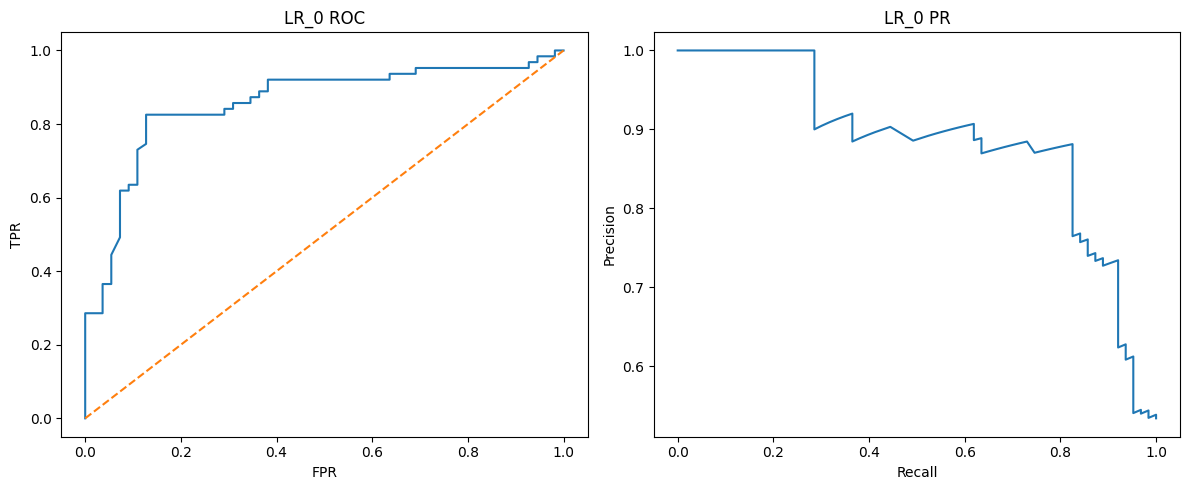

In [41]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y, prob_S)
prec, rec, _ = precision_recall_curve(y, prob_S)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"{algo}_{CV} ROC")

plt.subplot(1, 2, 2)
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{algo}_{CV} PR")

plt.tight_layout()
plt.show()
